# TS1: Síntesis y operaciones de señales

**Asignatura:** Análisis y Procesamiento de Señales  
**Autora:** Daniela Rolando  
**Fecha:** septiembre de 2026

---

## Introducción

El objetivo de este trabajo es sintetizar y analizar diferentes señales discretas mediante Python. En el **Ejercicio 1** se generan señales sinusoidales, secuencias de ruido y una señal rectangular, utilizando siempre $N=1000$ muestras. Para cada caso se representa la señal en el dominio temporal y el módulo de su Transformada Discreta de Fourier (DFT), calculada mediante la FFT.

También se incluyen los dos apartados bonus: la implementación de una forma de onda adicional de scipy.signal y la verificación del **teorema de Parseval**, que permite calcular la potencia media a partir de la Transformada de Fourier.

El **Ejercicio 2** se resuelve de forma analítica en papel. Sus fotografías se incorporan en la sección preparada al final del notebook.

## 1. Síntesis y análisis de señales

### Parámetros generales

La frecuencia de las señales periódicas es $f_0=2\,\mathrm{kHz}$. Para disponer de al menos 10 muestras por período se selecciona $f_s=20\,\mathrm{kHz}$:

$$
\frac{f_s}{f_0}=\frac{20000}{2000}=10\text{ muestras por período}
$$

Además, $f_s>2f_0$, por lo que también se satisface el criterio de Nyquist.

In [12]:
#%% IMPORTACION DE MODULOS

import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as sig
from pathlib import Path

plt.close('all')
plt.style.use('default')

#%% DEFINICION DE CONSTANTES

N = 1000               # Cantidad de muestras
ff = 2000              # Frecuencia de las señales [Hz]
fs = 20000             # Frecuencia de muestreo [Hz]
dc = 0                 # Valor medio
ph = 0                 # Fase inicial [rad]

tt = np.arange(N) / fs

# Semilla fija para que el resultado sea reproducible
rng = np.random.default_rng(2026)

print('Número de muestras:', N)
print('Frecuencia de la señal:', ff, 'Hz')
print('Frecuencia de muestreo:', fs, 'Hz')
print('Muestras por período:', fs / ff)

Número de muestras: 1000
Frecuencia de la señal: 2000 Hz
Frecuencia de muestreo: 20000 Hz
Muestras por período: 10.0


### Funciones utilizadas

La función gen_sin genera una señal sinusoidal a partir de su amplitud, componente continua, frecuencia y fase. La función representar_senal_fft calcula la FFT y representa conjuntamente los dominios temporal y frecuencial.

Como las señales son reales, se muestra el espectro unilateral entre $0$ y $f_s/2$. El módulo se normaliza dividiendo entre $N$ y se duplican las componentes interiores para conservar la amplitud.

In [13]:
#%% FUNCIONES

def gen_sin(Vmax=1, dc=0, ff=1, ph=0, nn=N, fs=fs):
    # Generador de una señal sinusoidal
    tt = np.arange(nn) / fs
    xx = dc + Vmax * np.sin(2 * np.pi * ff * tt + ph)
    return tt, xx


def calcular_espectro(xx, fs=fs):
    # FFT y vector de frecuencias unilateral
    XX = np.fft.rfft(xx)
    frec = np.fft.rfftfreq(len(xx), d=1/fs)

    # Normalizacion del modulo
    modulo_XX = np.abs(XX) / len(xx)
    if len(modulo_XX) > 2:
        modulo_XX[1:-1] = 2 * modulo_XX[1:-1]

    return frec, modulo_XX


def representar_senal_fft(tt, xx, titulo, unidad='V', color='tab:blue'):
    # Representacion temporal y frecuencial
    frec, modulo_XX = calcular_espectro(xx)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7))

    ax1.plot(tt * 1000, xx, color=color, linewidth=1.2,
             label=titulo)
    ax1.set_title(titulo + ' - Dominio temporal', fontweight='bold')
    ax1.set_xlabel('Tiempo [ms]')
    ax1.set_ylabel('Amplitud [' + unidad + ']')
    ax1.set_xlim(0, 5)
    ax1.legend(loc='upper right')
    ax1.grid(True, alpha=0.35)

    ax2.plot(frec / 1000, modulo_XX, color='tab:red',
             linewidth=1.2, label='Módulo de la FFT')
    ax2.set_title('Módulo de la Transformada de Fourier',
                  fontweight='bold')
    ax2.set_xlabel('Frecuencia [kHz]')
    ax2.set_ylabel('Amplitud espectral [' + unidad + ']')
    ax2.set_xlim(0, fs / 2000)
    ax2.legend(loc='upper right')
    ax2.grid(True, alpha=0.35)

    fig.tight_layout()
    plt.show()


def calcular_potencia(xx):
    # Potencia media en el dominio temporal
    potencia_tiempo = np.mean(np.abs(xx)**2)

    # Potencia mediante el teorema de Parseval
    XX = np.fft.fft(xx)
    potencia_parseval = np.sum(np.abs(XX)**2) / len(xx)**2

    return potencia_tiempo, potencia_parseval

### 1.1. Señal sinusoidal de 2 kHz

Se genera una señal sinusoidal de amplitud unidad:

$$
x_1[n]=\sin\left(2\pi f_0\frac{n}{f_s}\right)
$$

El enunciado no especifica la potencia o amplitud de esta primera señal, por lo que se escoge $A=1\,\mathrm{V}$.

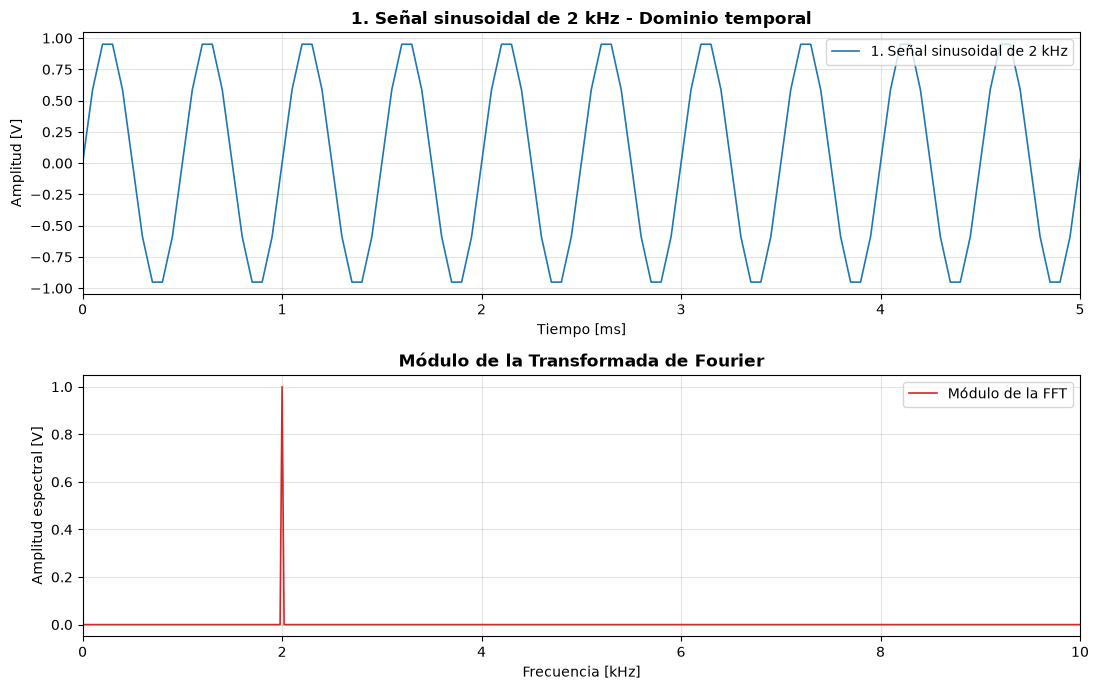

Potencia media de x1 = 0.5000000000000002 W


In [14]:
tt, x1 = gen_sin(Vmax=1, dc=dc, ff=ff, ph=ph, nn=N, fs=fs)

representar_senal_fft(tt, x1,
                      '1. Señal sinusoidal de 2 kHz',
                      unidad='V', color='tab:blue')

print('Potencia media de x1 =', np.mean(x1**2), 'W')

En el espectro unilateral se observa un pico en $2\,\mathrm{kHz}$, que corresponde a la frecuencia de la señal.

### 1.2. Señal sinusoidal de 2 W y fase $\pi/2$

Para una señal sinusoidal sin componente continua:

$$
P=\frac{A^2}{2}
$$

Para conseguir $P=2\,\mathrm{W}$:

$$
A=\sqrt{2P}=\sqrt{4}=2\,\mathrm{V}
$$

La señal generada es:

$$
x_2[n]=2\sin\left(2\pi f_0\frac{n}{f_s}+\frac{\pi}{2}\right)
$$

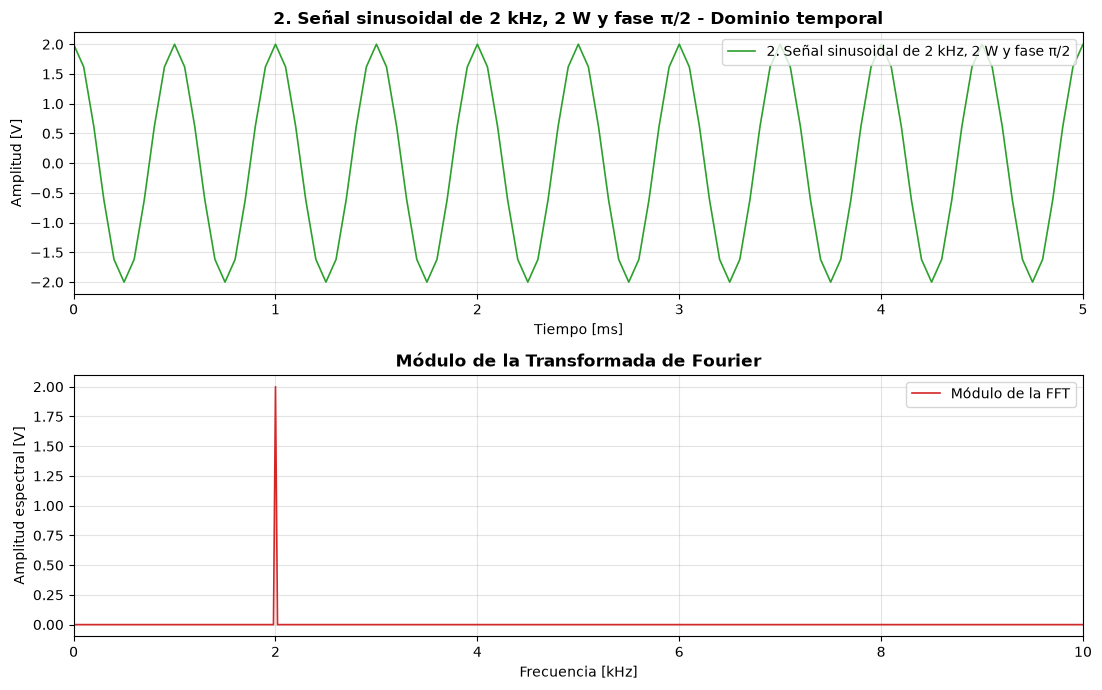

Amplitud utilizada = 2.0 V
Potencia media obtenida = 1.9999999999999991 W


In [15]:
Psen = 2                         # Potencia solicitada [W]
Vmax_2 = np.sqrt(2 * Psen)       # Amplitud pico [V]
ph_2 = np.pi / 2                 # Desfase [rad]

tt, x2 = gen_sin(Vmax=Vmax_2, dc=dc, ff=ff,
                 ph=ph_2, nn=N, fs=fs)

representar_senal_fft(tt, x2,
                      '2. Señal sinusoidal de 2 kHz, 2 W y fase π/2',
                      unidad='V', color='tab:green')

print('Amplitud utilizada =', Vmax_2, 'V')
print('Potencia media obtenida =', np.mean(x2**2), 'W')

El desfase modifica la posición temporal de la señal, pero no su frecuencia ni su potencia. La comprobación numérica proporciona una potencia media de $2\,\mathrm{W}$.

### 1.3. Ruido normalmente distribuido

Se genera una secuencia con distribución normal, media teórica $\mu=0$ y varianza $\sigma^2=0{,}1$. Como la función normal recibe la desviación estándar, se utiliza:

$$
\sigma=\sqrt{0{,}1}
$$

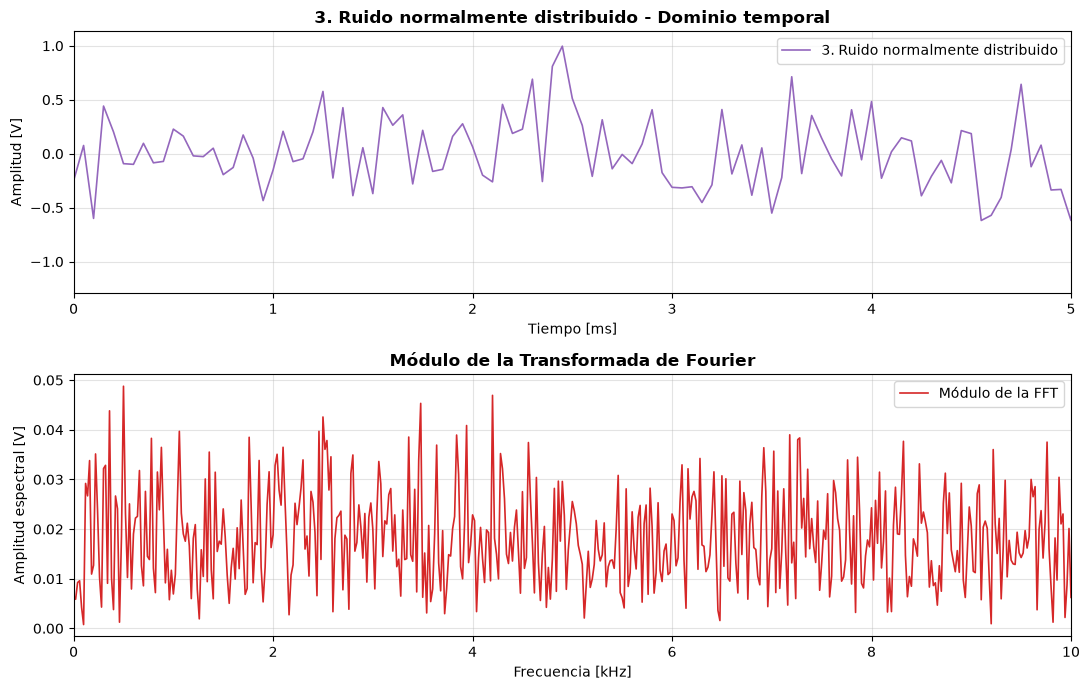

Media muestral = 0.006662039881905549 V
Varianza muestral = 0.10618387571013661 W


In [16]:
media_ruido = 0
var_ruido = 0.1
desv_est_ruido = np.sqrt(var_ruido)

ruido_normal = rng.normal(loc=media_ruido,
                          scale=desv_est_ruido,
                          size=N)

representar_senal_fft(tt, ruido_normal,
                      '3. Ruido normalmente distribuido',
                      unidad='V', color='tab:purple')

print('Media muestral =', np.mean(ruido_normal), 'V')
print('Varianza muestral =', np.var(ruido_normal), 'W')

Al tratarse de una realización aleatoria finita, la media y la varianza muestrales son próximas, pero no necesariamente idénticas, a sus valores teóricos. El contenido espectral se encuentra distribuido sobre todo el intervalo de frecuencias.

### 1.4. Ruido uniformemente distribuido

Para una variable uniforme $U(-a,a)$:

$$
E\{X\}=0,\qquad \operatorname{Var}\{X\}=\frac{a^2}{3}
$$

Al imponer una varianza de $0{,}1$:

$$
a=\sqrt{3\cdot0{,}1}=\sqrt{0{,}3}
$$

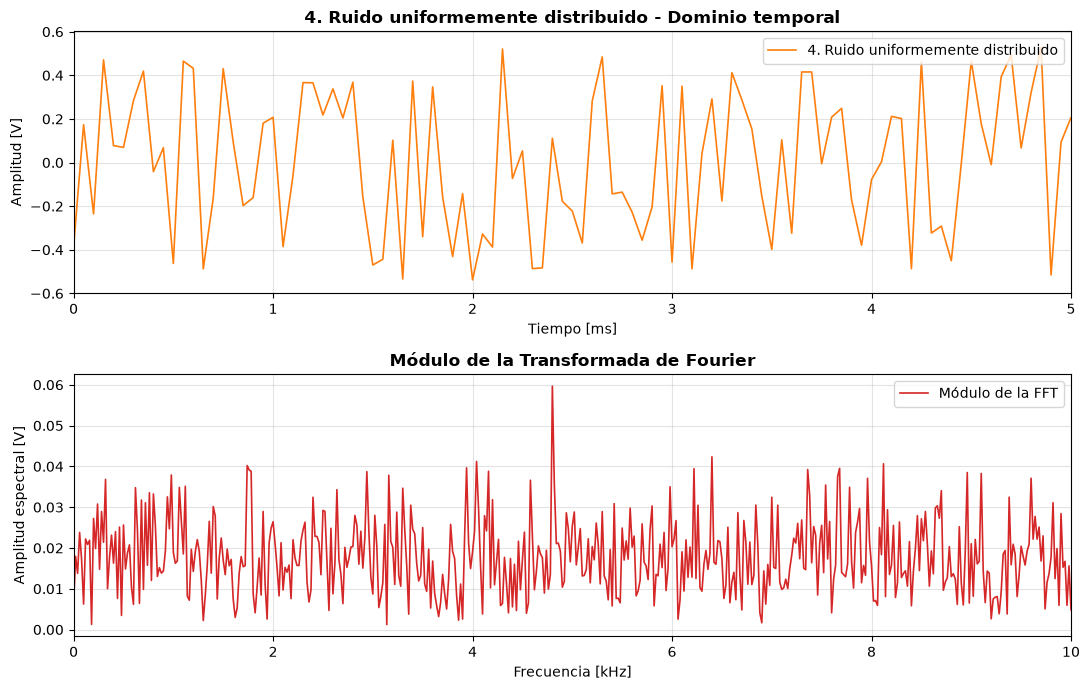

Límites de la distribución: [ -0.5477225575051662 , 0.5477225575051662 ] V
Media muestral = -0.006182586744566185 V
Varianza muestral = 0.10068404408120799 W


In [17]:
a = np.sqrt(3 * var_ruido)

ruido_uniforme = rng.uniform(low=-a, high=a, size=N)

representar_senal_fft(tt, ruido_uniforme,
                      '4. Ruido uniformemente distribuido',
                      unidad='V', color='tab:orange')

print('Límites de la distribución: [', -a, ',', a, '] V')
print('Media muestral =', np.mean(ruido_uniforme), 'V')
print('Varianza muestral =', np.var(ruido_uniforme), 'W')

Los valores muestrales se aproximan a la media cero y a la varianza $0{,}1$. La distribución uniforme limita las muestras al intervalo $[-\sqrt{0{,}3},\sqrt{0{,}3}]$.

### 1.5. Pulso rectangular de 2 kHz, 1 W y ciclo del 50 %

Se utiliza scipy.signal.square. Con un ciclo del 50 %, la señal permanece la mitad del período en $+1\,\mathrm{V}$ y la otra mitad en $-1\,\mathrm{V}$. Como $x^2[n]=1$, su potencia media es:

$$
P=\frac{1}{N}\sum_{n=0}^{N-1}|x[n]|^2=1\,\mathrm{W}
$$

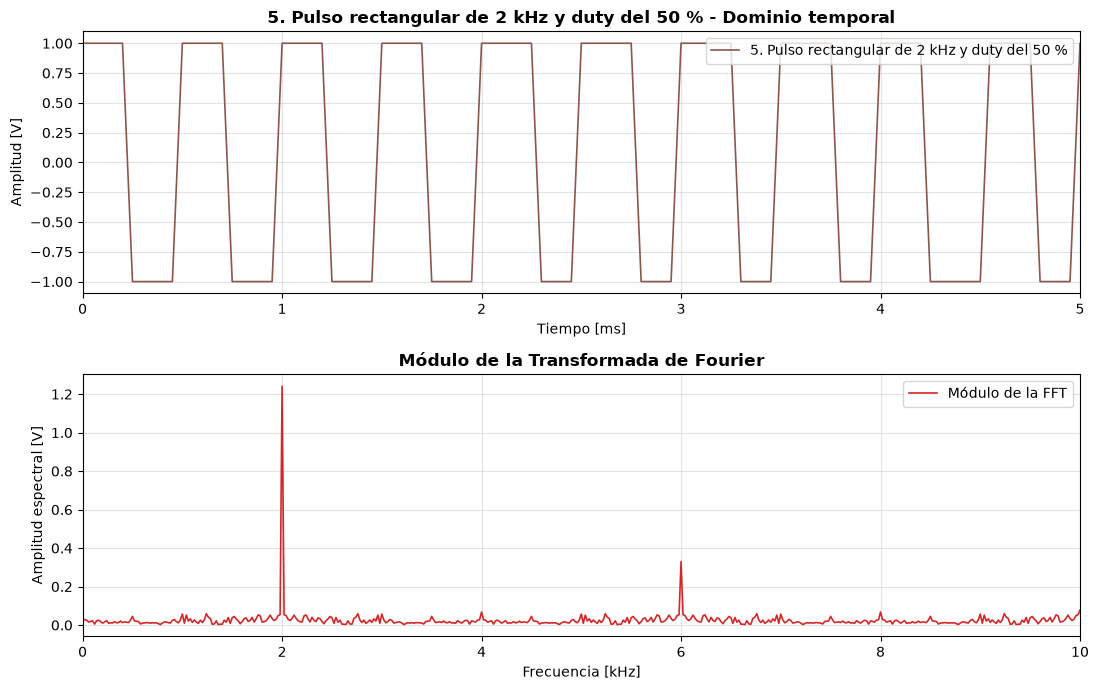

Ciclo de actividad = 50 %
Potencia media obtenida = 1.0 W


In [18]:
x5 = sig.square(2 * np.pi * ff * tt, duty=0.5)

representar_senal_fft(tt, x5,
                      '5. Pulso rectangular de 2 kHz y duty del 50 %',
                      unidad='V', color='tab:brown')

print('Ciclo de actividad = 50 %')
print('Potencia media obtenida =', np.mean(x5**2), 'W')

A diferencia de la sinusoide, el pulso rectangular contiene la frecuencia fundamental y armónicos impares. Por este motivo aparecen varios picos en su espectro.

## Bonus 1: señal adicional de scipy.signal

Se implementa una onda en diente de sierra mediante scipy.signal.sawtooth. Se mantiene la frecuencia de $2\,\mathrm{kHz}$ para poder comparar su espectro con los anteriores.

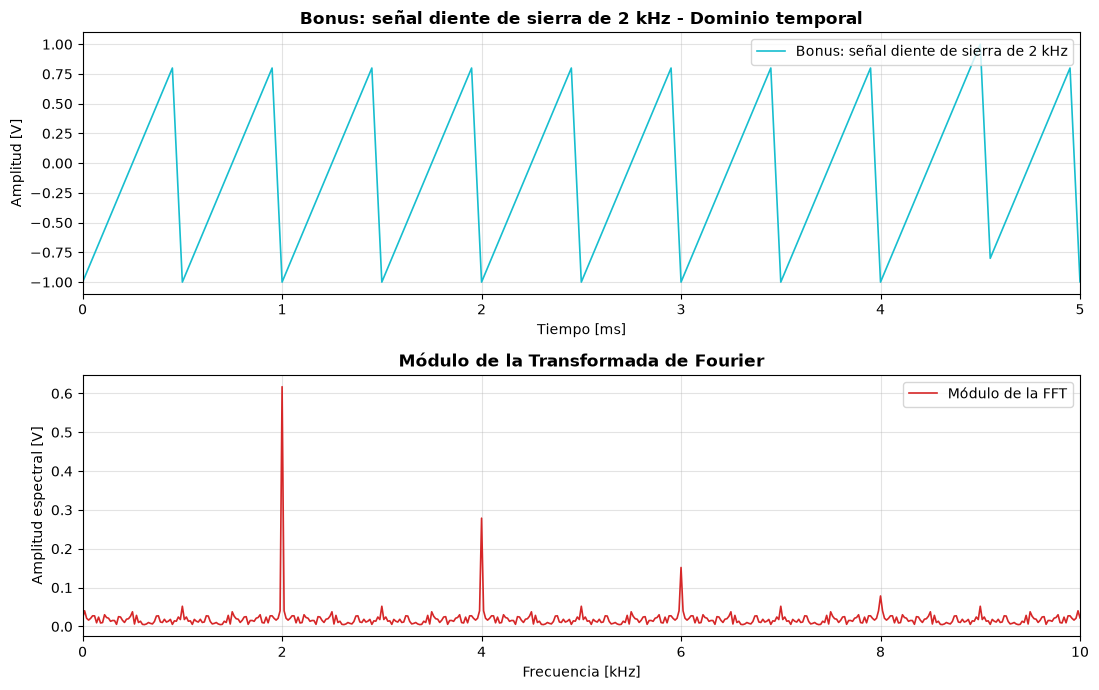

Potencia media del diente de sierra = 0.33999999999999836 W


In [19]:
x_bonus = sig.sawtooth(2 * np.pi * ff * tt)

representar_senal_fft(tt, x_bonus,
                      'Bonus: señal diente de sierra de 2 kHz',
                      unidad='V', color='tab:cyan')

print('Potencia media del diente de sierra =',
      np.mean(x_bonus**2), 'W')

La onda en diente de sierra presenta discontinuidades. Por ello, su espectro contiene la frecuencia fundamental y varios armónicos, tanto pares como impares.

## Bonus 2: potencia mediante el teorema de Parseval

Para la definición de DFT utilizada por NumPy:

$$
X[k]=\sum_{n=0}^{N-1}x[n]e^{-j2\pi kn/N}
$$

el teorema de Parseval establece:

$$
\sum_{n=0}^{N-1}|x[n]|^2
=\frac{1}{N}\sum_{k=0}^{N-1}|X[k]|^2
$$

Por tanto, la potencia media puede calcularse como:

$$
P=\frac{1}{N}\sum_{n=0}^{N-1}|x[n]|^2
=\frac{1}{N^2}\sum_{k=0}^{N-1}|X[k]|^2
$$

In [20]:
lista_senales = [x1, x2, ruido_normal, ruido_uniforme, x5, x_bonus]

nombres = ['Sinusoidal de amplitud 1 V',
           'Sinusoidal de 2 W',
           'Ruido normal',
           'Ruido uniforme',
           'Pulso rectangular',
           'Diente de sierra']

resultados = []

for nombre, xx in zip(nombres, lista_senales):
    potencia_tiempo, potencia_parseval = calcular_potencia(xx)

    resultados.append({
        'Señal': nombre,
        'Media [V]': np.mean(xx),
        'Varianza [W]': np.var(xx),
        'Potencia temporal [W]': potencia_tiempo,
        'Potencia por Parseval [W]': potencia_parseval,
        'Diferencia absoluta': abs(potencia_tiempo - potencia_parseval)
    })

print('{:<30} {:>16} {:>18} {:>14}'.format(
    'Señal', 'P temporal [W]', 'P Parseval [W]', 'Diferencia'))
print('-' * 84)

for fila in resultados:
    print('{:<30} {:>16.6f} {:>18.6f} {:>14.2e}'.format(
        fila['Señal'],
        fila['Potencia temporal [W]'],
        fila['Potencia por Parseval [W]'],
        fila['Diferencia absoluta']))

Señal                            P temporal [W]     P Parseval [W]     Diferencia
------------------------------------------------------------------------------------
Sinusoidal de amplitud 1 V             0.500000           0.500000       2.22e-16
Sinusoidal de 2 W                      2.000000           2.000000       8.88e-16
Ruido normal                           0.106228           0.106228       0.00e+00
Ruido uniforme                         0.100722           0.100722       2.78e-17
Pulso rectangular                      1.000000           1.000000       0.00e+00
Diente de sierra                       0.340000           0.340000       0.00e+00


---

## 2. Resolución analítica: convolución y DFT

A continuación se adjunta la resolución manuscrita del Ejercicio 2, realizada mediante las propiedades de la convolución y la Transformada Discreta de Fourier.

### Apartados a), b) y c)

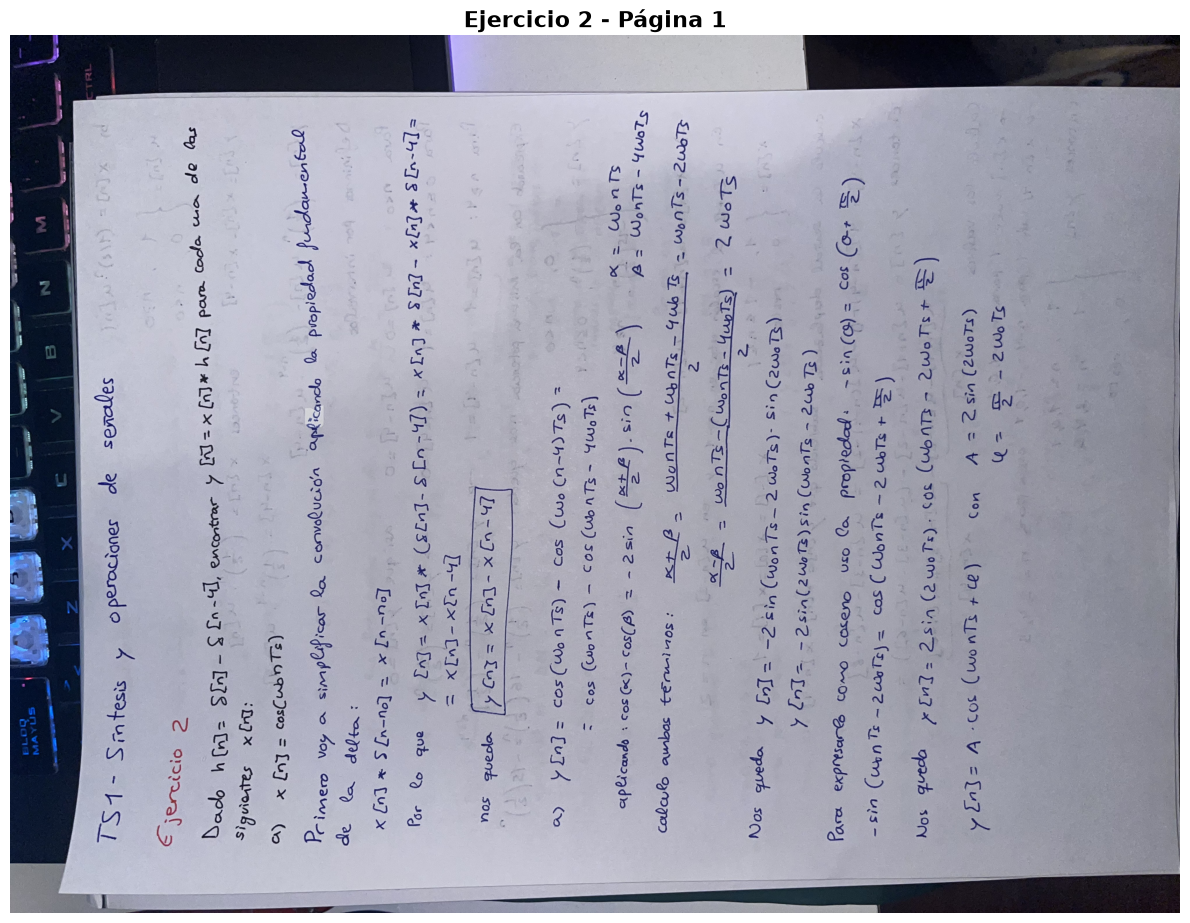

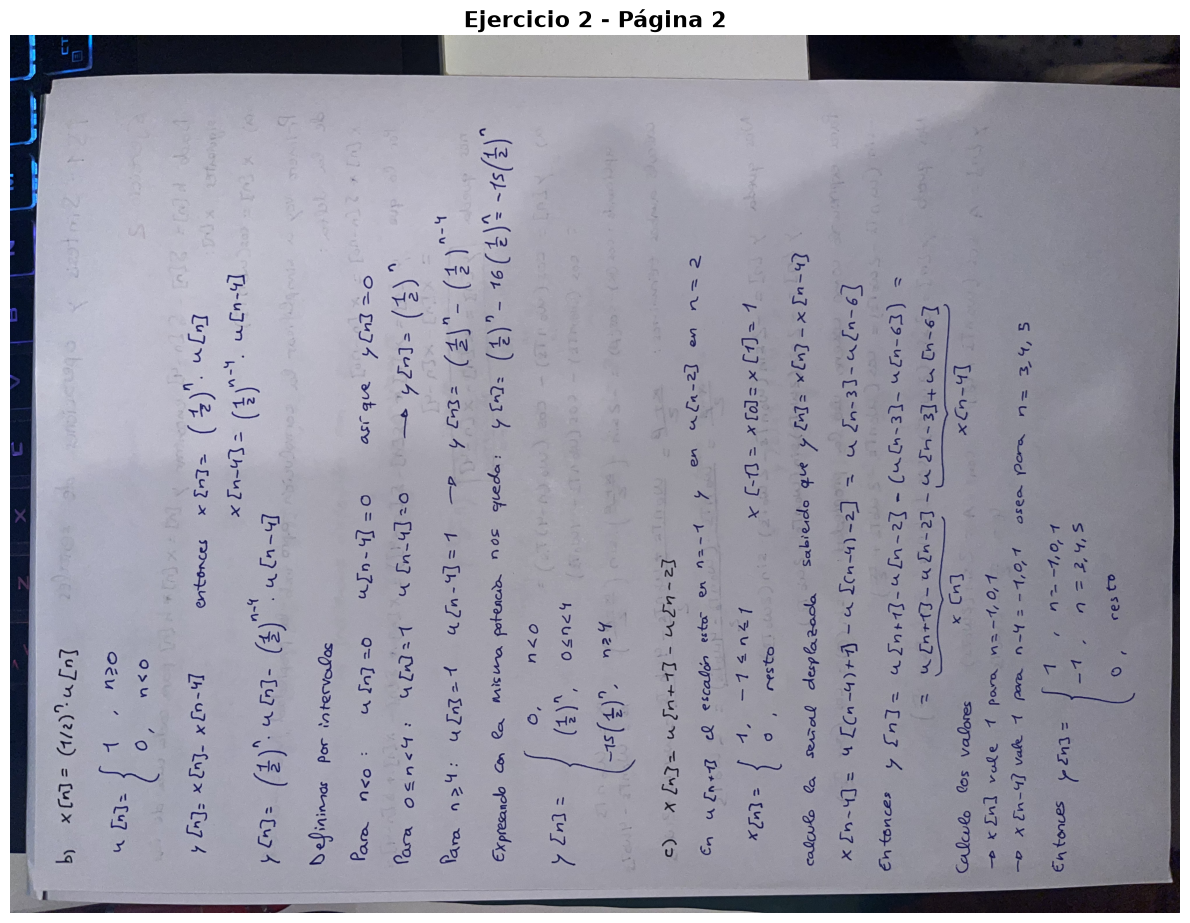

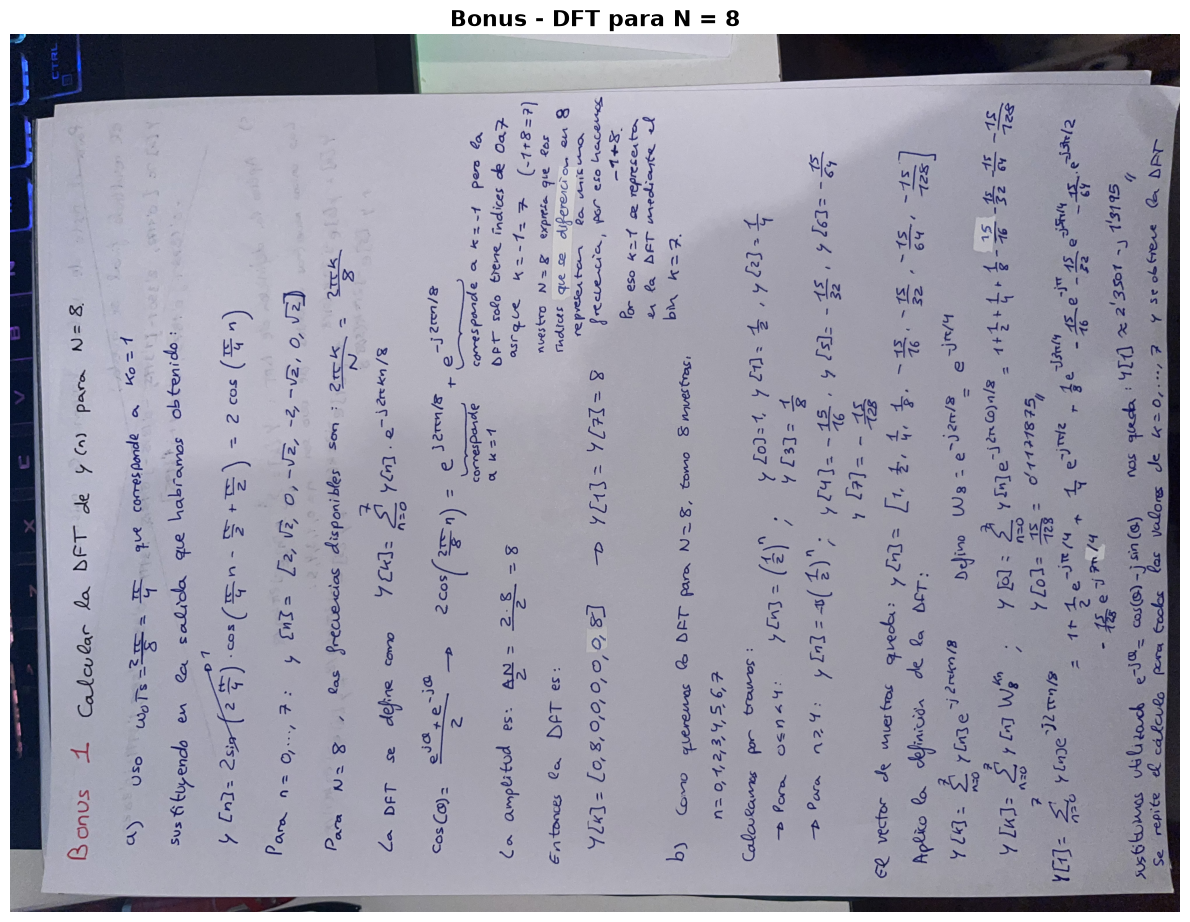

In [26]:
#%% FOTOGRAFÍAS DEL EJERCICIO 2 Y DEL BONUS

fotos = [
    ('Ejercicio 2 - Página 1', 'TP0-Daniela/TS1/EJ2.1.jpeg'),
    ('Ejercicio 2 - Página 2', 'TP0-Daniela/TS1/EJ2.2.jpeg'),
    ('Bonus - DFT para N = 8', 'TP0-Daniela/TS1/BONUS1.jpeg')
]

for titulo, nombre_archivo in fotos:

    imagen = plt.imread(nombre_archivo)

    plt.figure(figsize=(12, 16))
    plt.imshow(imagen)
    plt.title(titulo, fontsize=16, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

### Bonus: cálculo de la DFT para N = 8

A continuación se incluye la resolución manuscrita del apartado bonus.

In [ ]:
#%% FOTOGRAFIA DEL BONUS

import matplotlib.pyplot as plt
from pathlib import Path

ruta_bonus = Path('BONUS1.jpeg')

if ruta_bonus.exists():

    imagen_bonus = plt.imread(ruta_bonus)

    plt.figure(figsize=(12, 16))
    plt.imshow(imagen_bonus)
    plt.title('Bonus - DFT para N = 8',
              fontsize=16, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

else:
    print('No se ha encontrado el archivo BONUS1.jpeg')

---

## Conclusiones

En este trabajo se han sintetizado correctamente cinco tipos de señales utilizando $N=1000$ muestras y una frecuencia de muestreo de $20\,\mathrm{kHz}$. Esta elección proporciona 10 muestras por período para las señales de $2\,\mathrm{kHz}$ y cumple el criterio de Nyquist.

El análisis mediante la FFT ha permitido identificar sus diferencias espectrales. Las señales sinusoidales concentran su contenido en la frecuencia fundamental, mientras que las señales rectangular y de diente de sierra presentan armónicos debido a sus discontinuidades. Las secuencias de ruido distribuyen su contenido sobre un intervalo amplio de frecuencias.

También se han comprobado las propiedades estadísticas solicitadas. Las realizaciones de ruido presentan una media próxima a cero y una varianza próxima a $0{,}1$, teniendo en cuenta que se trabaja con un número finito de muestras. La segunda sinusoide y el pulso rectangular alcanzan respectivamente las potencias requeridas de $2\,\mathrm{W}$ y $1\,\mathrm{W}$.

Finalmente, el teorema de Parseval se ha verificado comparando la potencia calculada en el dominio temporal con la obtenida a partir de la FFT. La coincidencia entre ambos resultados confirma la equivalencia del análisis de potencia en los dominios temporal y frecuencial.

C:\Users\Carolina naturia\Documents\APS\pdstestbench
['.git', '.gitignore', '.ipynb_checkpoints', 'adc_oversampled_sim.py', 'adc_sigma_delta_sim.py', 'adc_sim.py', 'blackman_tukey.py', 'Clase27ag.ipynb', 'DFT primeras pruebas.ipynb', 'ecg_sin_ruido.npy', 'ECG_TP4.mat', 'esqueleto_ej_cuantizacion.py', 'fft_prueba.py', 'intro_a_python.py', 'la cucaracha.wav', 'lapiz_y_papel.pdf', 'leakage.py', 'lectura_sigs.py', 'LICENSE', 'LICENSE.md', 'logo_UNSAM.jpg', 'logo_UTN.svg', 'mi_senoidal.py', 'notebook0-UNSAM.ipynb', 'notebook0.ipynb', 'pdsmodulos', 'pdsmodulos.py', 'periodograma.py', 'PPG.csv', 'ppg_sin_ruido.npy', 'preparacion-UNSAM.ipynb', 'prueba psd.wav', 'prueba.py', 'pruebas clase.py', 'psd.py', 'psd_demo.ipynb', 'quantization.py', 'README.md', 'recetas_ubuntu-UNSAM.ipynb', 'recetas_windows-UNSAM.ipynb', 'rect_win.py', 'silbido.wav', 'sound_rec.py', 'testbench0.py', 'testbench1.py', 'TP0-Daniela', 'TS1_Daniela_Rolando.ipynb', 'TS1_Daniela_Rolando_FINAL.ipynb', 'ventanas.py']


FileNotFoundError: [Errno 2] No such file or directory: 'TPO-Daniela/TS1/EJ2.1.jpeg'